In [1]:
import pandas as pd
import numpy as np
# from tqdm import tqdm
# ============================================================
# 1. Cargar dataset
# ============================================================
# SAVE_DIR = "/content/drive/MyDrive/KYUTECH/Lab research/Research/Anomaly Detection ADCS/Coding/dataset/windowed/"
SAVE_DIR = "./dataset_windows20/"

X = np.load(SAVE_DIR + "X_windows.npy")     # shape: (N, 20, num_features)
y_bin = np.load(SAVE_DIR + "y_binary.npy")  # shape: (N,)
y_ch  = np.load(SAVE_DIR + "y_channel.npy") # shape: (N,), 0 = no fault, 1..18 canal

N, W, F = X.shape

print("=====================================")
print(" Dataset loaded successfully ")
print("=====================================")
print(f"Total windows: {N}")
print(f"Window size: {W}")
print(f"Number of features: {F}")
print(f"Anomalous windows: {sum(y_bin)}")
print(f"Nominal windows: {N - sum(y_bin)}")
print(f"Percentage anomalies: {100 * sum(y_bin)/N:.2f}%")
print("=====================================\n")

 Dataset loaded successfully 
Total windows: 399982
Window size: 20
Number of features: 20
Anomalous windows: 274971
Nominal windows: 125011
Percentage anomalies: 68.75%



In [2]:
import numpy as np

idx_nom = np.where(y_bin == 0)[0]
idx_anom = np.where(y_bin == 1)[0]

print("Nominal windows:", len(idx_nom))
print("Anomalous windows:", len(idx_anom))


Nominal windows: 125011
Anomalous windows: 274971


In [3]:
## Preprocessing

In [4]:
# separar nominales
X_nom = X[y_bin == 0]   # (N_nom, 20, num_features)
# calcular μ y σ por feature
mean_feat = X_nom.mean(axis=(0,1))   # (num_features,)
std_feat  = X_nom.std(axis=(0,1)) + 1e-8
# escalar TODO el dataset
def scale_windows(X, mean, std):
    return (X - mean[None,None,:]) / std[None,None,:]

X_scaled = scale_windows(X, mean_feat, std_feat)


In [7]:
def time_domain_features(x):
    eps = 1e-8
    N = len(x)

    mu = np.mean(x)
    std = np.std(x, ddof=1) + eps

    rms = np.sqrt(np.mean(x**2))
    sra = (np.mean(np.sqrt(np.abs(x))) + eps) ** 2

    max_v = np.max(x)
    min_v = np.min(x)
    abs_max = np.max(np.abs(x))

    mean_abs = np.mean(np.abs(x))

    sv = np.mean(((x - mu) / std) ** 3)
    kv = np.mean(((x - mu) / std) ** 4)

    return np.array([
        mu, std, max_v, min_v,
        rms, sra,
        kv, sv,
        max_v - min_v,            # PPV
        abs_max / rms,            # CF
        abs_max / mean_abs,       # IF
        abs_max / sra             # MF
    ])
import pywt

def wavelet_features_1d(x, wavelet="db4", level=3):
    coeffs = pywt.wavedec(x, wavelet, level=level)

    A = coeffs[0]
    Ds = coeffs[1:]

    EA = np.sum(A**2)
    ED = [np.sum(d**2) for d in Ds]
    RMSD = [np.sqrt(np.mean(d**2)) for d in Ds]

    return np.hstack([EA, *ED, *RMSD])
def extract_features(X):
    feats = []

    for w in X:               # (20, num_features)
        f_w = []
        for ch in range(w.shape[1]):
            x = w[:, ch]

            f_ch = np.hstack([
                time_domain_features(x),
                wavelet_features_1d(x)
            ])

            f_w.append(f_ch)

        feats.append(np.hstack(f_w))

    return np.array(feats)



In [8]:
X_feat = extract_features(X_scaled)
print("Feature matrix:", X_feat.shape)


/opt/conda/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Feature matrix: (399982, 380)


In [10]:
X_feat = np.nan_to_num(
    X_feat,
    nan=np.nan,
    posinf=np.nan,
    neginf=np.nan
)


In [11]:
X_nom = X_feat[y_bin == 0]

mu_nom = X_nom.mean(axis=0)
std_nom = X_nom.std(axis=0)

k = 2   # sensitivity
upper_th = mu_nom + k * std_nom
lower_th = mu_nom - k * std_nom


In [12]:
def adaptive_threshold_detector(feat, low, high):
    return int(np.any((feat < low) | (feat > high)))

y_pred = np.array([
    adaptive_threshold_detector(f, lower_th, upper_th)
    for f in X_feat
])


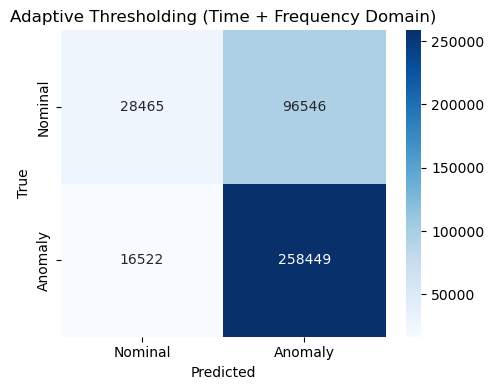

              precision    recall  f1-score   support

           0     0.6327    0.2277    0.3349    125011
           1     0.7280    0.9399    0.8205    274971

    accuracy                         0.7173    399982
   macro avg     0.6804    0.5838    0.5777    399982
weighted avg     0.6983    0.7173    0.6687    399982



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_bin, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal", "Anomaly"],
    yticklabels=["Nominal", "Anomaly"]
)
plt.title("Adaptive Thresholding (Time + Frequency Domain)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(y_bin, y_pred, digits=4))


In [15]:
## Dataset split

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (319985, 380) Test: (79997, 380)


In [17]:
# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Solo nominal para entrenar PCA
X_train_nom = X_train_s[y_train == 0]

pca = PCA(n_components=0.95)  # conserva 95% varianza
pca.fit(X_train_nom)


PCA(n_components=0.95)

In [42]:
# Error de reconstrucción en nominal
X_rec = pca.inverse_transform(pca.transform(X_train_nom))
recon_error = np.mean((X_train_nom - X_rec)**2, axis=1)

mu, sigma = recon_error.mean(), recon_error.std()
k = 1
threshold = mu + 0.000001 * sigma


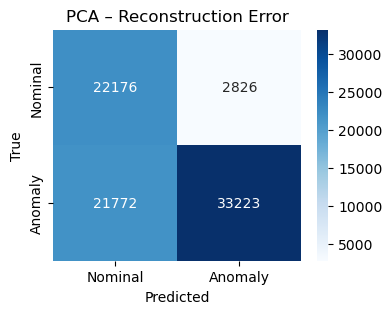

              precision    recall  f1-score   support

           0     0.5046    0.8870    0.6432     25002
           1     0.9216    0.6041    0.7298     54995

    accuracy                         0.6925     79997
   macro avg     0.7131    0.7455    0.6865     79997
weighted avg     0.7913    0.6925    0.7028     79997



In [43]:
X_test_rec = pca.inverse_transform(pca.transform(X_test_s))
test_error = np.mean((X_test_s - X_test_rec)**2, axis=1)

y_pred_pca = (test_error > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Nominal","Anomaly"],
            yticklabels=["Nominal","Anomaly"])
plt.title("PCA – Reconstruction Error")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred_pca, digits=4))


In [ ]:
# SVM
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

svm.fit(X_train_s, y_train)

y_pred_svm = svm.predict(X_test_s)


In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Nominal","Anomaly"],
            yticklabels=["Nominal","Anomaly"])
plt.title("SVM (RBF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred_svm, digits=4))


In [ ]:
#CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# (N, F) → (N, F, 1)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
history = model.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


In [ ]:
y_prob = model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Nominal","Anomaly"],
            yticklabels=["Nominal","Anomaly"])
plt.title("CNN Simple (Features)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred_cnn, digits=4))
